In [48]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from astropy.io import fits
import matplotlib.animation as animation 
from tqdm import tqdm   

In [46]:
pa = np.linspace(0, 180, 240)

In [45]:
input_path = '/Users/ainsleylewis/Documents/Astronomy/TestLens/input/extend.input'

with open(input_path, 'r') as fin:
    lines = fin.readlines()

with open(input_path, 'w') as fout:
    for line in lines:
        if line.startswith('lens mpole'):
            parts = line.split()
            parts[7] = str(pa)  # Replace the 6th parameter (index 6) with pa
            fout.write(' '.join(parts) + '\n')
        else:
            fout.write(line)



In [22]:
data = fits.open('/Users/ainsleylewis/Documents/Astronomy/TestLens/out/extend_image.fits')
data = data[0].data

In [36]:
os.chdir('/Users/ainsleylewis/glafic2')

In [52]:
df = []

In [53]:
for i in tqdm(range(len(pa)), desc="Processing frames"):
    with open(input_path, 'r') as fin:
        lines = fin.readlines()

    with open(input_path, 'w') as fout:
        for line in lines:
            if line.startswith('lens mpole'):
                parts = line.split()
                parts[7] = str(pa[i])  # Replace the 6th parameter (index 6) with pa
                fout.write(' '.join(parts) + '\n')
            else:
                fout.write(line)
    
    os.system('./glafic /Users/ainsleylewis/Documents/Astronomy/TestLens/input/extend.input')
    data = fits.open('/Users/ainsleylewis/Documents/Astronomy/TestLens/out/extend_image.fits')
    data = data[0].data

    df.append(data)

    

Processing frames:   0%|          | 0/240 [00:00<?, ?it/s]
glafic  ver. 2.1.10 (2024.10.02) by Masamune Oguri

######## parameter definition
omega    =  3.000000e-01
lambda   =  7.000000e-01
weos     =  -1.000000e+00
hubble   =  7.000000e-01
prefix   =  /Users/ainsleylewis/Documents/Astronomy/TestLens/out/extend
xmin     =  -5.000000e+01
ymin     =  -5.000000e+01
xmax     =  5.000000e+01
ymax     =  5.000000e+01
pix_ext  =  2.000000e-01
nx_ext   =  500
ny_ext   =  500
pix_poi  =  3.000000e+00
nx_poi   =  33
ny_poi   =  33
maxlev   =  5

flag_extnorm    =  1
obs_gain        =  3.000000e+00
obs_ncomb       =  3
obs_readnoise   =  1.000000e+01
flag_srcsbin    =  1

######## startup
lens   pow     0.3000  4.000000e-01  0.000000e+00  0.000000e+00  5.000000e-01  4.500000e+01  8.000000e+00  2.600000e+00 
lens   mpole   0.3000  4.000000e-01  0.000000e+00  0.000000e+00  1.000000e-02  0.000000e+00  4.000000e+00  2.600000e+00 
extend sersic  0.5000  5.000000e+10  0.000000e+00  0.000000e+00  6.000

Saving animation to /Users/ainsleylewis/Documents/Astronomy/TestLens/plots/extend_animation.mov
Saved animation.
Saved animation.


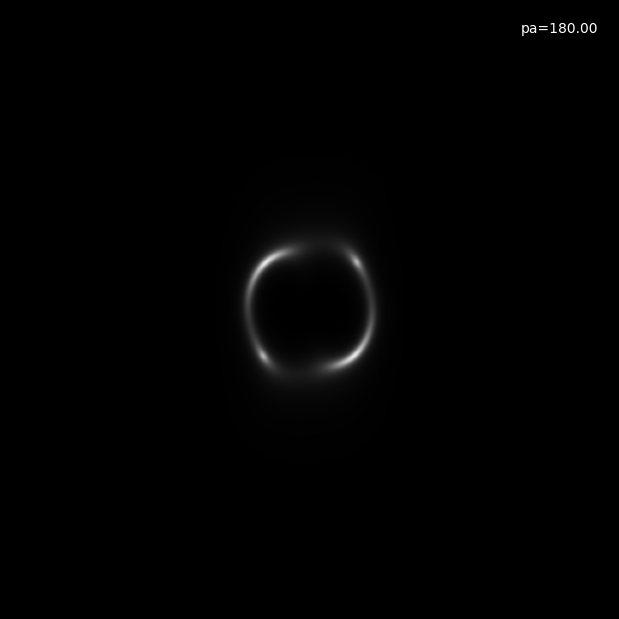

In [54]:
# Convert list of arrays to a movie 
# Convert list of arrays (df) to a movie at 24 fps for 10 seconds (240 frames).
import matplotlib as mpl
# Use ffmpeg writer if available
from matplotlib.animation import FFMpegWriter

# Ensure df and pa exist and have matching length
nframes = len(df)
assert nframes == len(pa), f'Expected df and pa to have same length; got {nframes} and {len(pa)}'
fps = 24
duration_s = 10
# Guard: ensure duration matches frames/fps (optional)
if nframes != fps * duration_s:
    print(f'Warning: nframes={nframes} does not equal fps*duration ({fps*duration_s}); animation length will be nframes/fps s')

# Create figure with black background and no axes
fig, ax = plt.subplots(figsize=(6,6), facecolor='black')
ax.set_axis_off()
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

# Normalize images across all frames for consistent colormap scaling
all_min = min(arr.min() for arr in df)
all_max = max(arr.max() for arr in df)
norm = mpl.colors.Normalize(vmin=all_min, vmax=all_max)

# Show first frame
im = ax.imshow(df[0], cmap='gray', origin='lower', norm=norm)
# Remove axes ticks/labels explicitly
ax.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

# Small textbox in top-right showing pa value
textbox = ax.text(0.98, 0.98, f'pa={pa[0]:.2f}', color='white', fontsize=10, ha='right', va='top', transform=ax.transAxes, bbox=dict(facecolor='black', alpha=0.6, edgecolor='none'))

def update(frame):
    im.set_data(df[frame])
    textbox.set_text(f'pa={pa[frame]:.2f}')
    return im, textbox

# Prepare writer (mov via ffmpeg)
output_path = '/Users/ainsleylewis/Documents/Astronomy/TestLens/plots/extend_animation.mov'
metadata = dict(title='extend animation', artist='matplotlib')
writer = FFMpegWriter(fps=fps, metadata=metadata)

# Save animation
ani = animation.FuncAnimation(fig, update, frames=nframes, blit=True)
print('Saving animation to', output_path)
ani.save(output_path, writer=writer, dpi=200)
print('Saved animation.')